<a href="https://colab.research.google.com/github/WhiteBearCode02/hangul-hw-recognition/blob/main/%EC%9D%B8%EA%B3%B5%EC%A7%80%EB%8A%A5%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
"""
===============================================================================
[GitHub Commit]
chore: 대용량 데이터 I/O 병목 해결을 위한 Colab 로컬 환경 데이터 로드 스크립트 추가

[기능 설명]
구글 드라이브(클라우드 스토리지)에 업로드된 대용량 .zip 파일들을 코랩 가상머신의
로컬 디스크(/content/Raw_Data)로 복사합니다.

[알고리즘 및 구성 이유]
- 네트워크 I/O 최소화 알고리즘: 수만 개의 파일을 클라우드에서 직접 압축 해제하면
  API 호출 딜레이로 인해 엄청난 병목 현상(Overhead)이 발생합니다. 이를 방지하기 위해
  단일 대용량 zip 파일을 로컬(NVMe SSD)로 먼저 통째로 복사한 뒤 처리하는 방식을 채택했습니다.
===============================================================================
"""
"""
AI-Hub에서 다양한 형태의 한글 문자 OCR 다운
그중에서 Training, Validation에서 각각 라벨, 원천의 필기체 다운로드
다운 받은 후 본인의 드라이브에 올린 후 실행해야 결과 값 나옴.
로컬 저장소에 저장 후 사용하는 것은 경로를 수정해야함.
"""
import os
import shutil
from google.colab import drive

# 1. 구글 드라이브 마운트 (연결)
drive.mount('/content/drive', force_remount=True)

# 2. 로컬 작업용 베이스 디렉토리 생성
local_raw_dir = '/content/Raw_Data'
os.makedirs(local_raw_dir, exist_ok=True)

# 3. 가져올 대용량 파일 목록 정의 (드라이브 최상단 기준)
zip_files = [
    '[원천]Training_필기체.zip',
    '[라벨]Training_필기체.zip',
    '[원천]validation_필기체.zip',
    '[라벨]validation_필기체.zip'
]

print("🚀 구글 드라이브에서 로컬 시스템으로 대용량 데이터 복사를 시작합니다...")

# 4. 파일 복사 루프
for file_name in zip_files:
    source_path = os.path.join('/content/drive/MyDrive', file_name)
    destination_path = os.path.join(local_raw_dir, file_name)

    if os.path.exists(source_path):
        if not os.path.exists(destination_path):
            print(f" -> 📥 복사 중: {file_name}")
            shutil.copy2(source_path, destination_path)
            print(f"    ✅ 완료!")
        else:
            print(f" -> ⏩ 이미 존재함 (건너뜀): {file_name}")
    else:
        print(f" -> ❌ 파일을 찾을 수 없습니다 (경로 확인 필요): {source_path}")

print("\n🎉 모든 데이터가 Colab 로컬 디스크로 안전하게 이동되었습니다!")

Mounted at /content/drive
🚀 구글 드라이브에서 로컬 시스템으로 대용량 데이터 복사를 시작합니다...
 -> ⏩ 이미 존재함 (건너뜀): [원천]Training_필기체.zip
 -> ⏩ 이미 존재함 (건너뜀): [라벨]Training_필기체.zip
 -> ⏩ 이미 존재함 (건너뜀): [원천]validation_필기체.zip
 -> ⏩ 이미 존재함 (건너뜀): [라벨]validation_필기체.zip

🎉 모든 데이터가 Colab 로컬 디스크로 안전하게 이동되었습니다!


In [2]:
"""
===============================================================================
[GitHub Commit]
feat: Hash Map 기반 시간 복잡도 O(1) 최적화 데이터 필터링 파이프라인 구현

[기능 설명]
로컬에 복사된 압축 파일들을 해제하고, 수십만 개의 JSON 라벨을 분석하여
타겟 음절('가, 나, 다, 라, 마')에 해당하는 원천 이미지 파일만 Final_Dataset 폴더로 복사합니다.

[알고리즘 및 구성 이유]
- Hash Map (Dictionary) 탐색 알고리즘: 깊은 계층 구조(001~122)를 가진 디렉토리에서
  특정 이미지를 찾기 위해 매번 선형 탐색(O(N))을 하면 엄청난 연산량이 필요합니다.
  이를 해결하기 위해 이미지의 파일명을 Key, 절대 경로를 Value로 갖는 Hash Map을 메모리에
  캐싱하여 탐색 시간 복잡도를 O(1)로 혁신적으로 줄였습니다.
===============================================================================
"""

import os
import zipfile
import json
import shutil
import time

# 1. 경로 설정
raw_dir = '/content/Raw_Data'
label_dir = os.path.join(raw_dir, 'labels')
img_dir = os.path.join(raw_dir, 'images')
target_base_dir = '/content/Final_Dataset'

target_letters = ['가', '나', '다', '라', '마']

# 폴더 초기화
os.makedirs(label_dir, exist_ok=True)
os.makedirs(img_dir, exist_ok=True)
for letter in target_letters:
    os.makedirs(os.path.join(target_base_dir, letter), exist_ok=True)

start_time = time.time()

# 2. 압축 해제 로직
print("📦 1단계: 업로드된 ZIP 파일 로컬 압축 해제 중...")
for file in os.listdir(raw_dir):
    if file.endswith('.zip'):
        zip_path = os.path.join(raw_dir, file)
        if '라벨' in file or 'label' in file.lower():
            print(f" -> 📄 라벨 데이터 푸는 중: {file}")
            with zipfile.ZipFile(zip_path, 'r') as z: z.extractall(label_dir)
        else:
            print(f" -> 🖼️ 원천 이미지 데이터 푸는 중: {file}")
            with zipfile.ZipFile(zip_path, 'r') as z: z.extractall(img_dir)

# 3. Hash Map 생성 (핵심 알고리즘)
print("\n🔍 2단계: 초고속 매칭을 위한 이미지 인덱스(Hash Map) 생성 중...")
image_map = {}
for root, _, files in os.walk(img_dir):
    for f in files:
        if f.endswith(('.jpg', '.png', '.jpeg')):
            image_map[f] = os.path.join(root, f)
print(f" -> ✅ 총 {len(image_map)}개의 이미지 경로 매핑 완료!")

# 4. JSON 필터링 및 매칭
print("\n🚀 3단계: '가~마' 타겟 데이터 정밀 추출 및 병합 시작...")
count = 0
for root, _, files in os.walk(label_dir):
    for file in files:
        if file.endswith('.json'):
            with open(os.path.join(root, file), 'r', encoding='utf-8') as f:
                try:
                    data = json.load(f)
                    letter = data['text']['letter']['value']

                    if letter in target_letters:
                        img_name = data['image']['file_name']
                        src_img_path = image_map.get(img_name) # Hash Map에서 즉시 탐색

                        if src_img_path:
                            dst_img_path = os.path.join(target_base_dir, letter, img_name)
                            if not os.path.exists(dst_img_path): # 중복 복사 방지
                                shutil.copy2(src_img_path, dst_img_path)
                                count += 1
                except (KeyError, json.JSONDecodeError):
                    continue

end_time = time.time()
print(f"\n🎉 모든 전처리 완료! 총 {count}개의 정예 학습 데이터를 확보했습니다.")
print(f"⏱️ 총 소요 시간: {end_time - start_time:.2f}초")

📦 1단계: 업로드된 ZIP 파일 로컬 압축 해제 중...
 -> 🖼️ 원천 이미지 데이터 푸는 중: [원천]Training_필기체.zip
 -> 📄 라벨 데이터 푸는 중: [라벨]Training_필기체.zip
 -> 📄 라벨 데이터 푸는 중: [라벨]validation_필기체.zip
 -> 🖼️ 원천 이미지 데이터 푸는 중: [원천]validation_필기체.zip

🔍 2단계: 초고속 매칭을 위한 이미지 인덱스(Hash Map) 생성 중...
 -> ✅ 총 990886개의 이미지 경로 매핑 완료!

🚀 3단계: '가~마' 타겟 데이터 정밀 추출 및 병합 시작...

🎉 모든 전처리 완료! 총 671개의 정예 학습 데이터를 확보했습니다.
⏱️ 총 소요 시간: 824.25초


In [3]:
"""
===============================================================================
[GitHub Commit]
feat: Baseline SimpleCNN 모델 구조 정의 및 8:2 Train/Val 학습 파이프라인 구축

[기능 설명]
PyTorch를 이용하여 전처리된 이미지 데이터를 텐서(Tensor)로 변환하고,
직접 설계한 SimpleCNN 아키텍처를 통해 한글 5개 음절을 분류하는 모델을 학습시킵니다.

[알고리즘 및 구성 이유]
- CNN(합성곱 신경망) 구조: 이미지의 공간적 특성을 보존하며 특징(Feature)을 추출하기
  위해 Conv2d 계층을 사용했습니다.
- Train/Validation 분할 알고리즘 (random_split): 전체 데이터를 8:2 비율로 분할하여,
  모델이 학습 데이터에만 억지로 끼워 맞춰지는 '과적합(Overfitting)' 현상을 방지하고
  실제 새로운 데이터에 대한 '일반화(Generalization) 성능'을 검증하기 위해 구성했습니다.
===============================================================================
"""

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import os

# 1. 모델 아키텍처 정의 (SimpleCNN)
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(16 * 64 * 64, 5) # 5개 음절 분류기

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = x.view(x.size(0), -1) # Flatten (1차원으로 전개)
        x = self.fc1(x)
        return x

# 2. 시스템 및 GPU 환경 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 현재 학습에 사용 중인 연산 장치: {device}")
model = SimpleCNN().to(device)

# 3. 데이터 로드 및 정규화 (Normalization) 전처리
data_dir = '/content/Final_Dataset'
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # 학습 안정성을 위한 정규화
])

# ImageFolder를 이용한 라벨 자동 매핑
dataset = datasets.ImageFolder(data_dir, transform=transform)

# 4. Train / Validation 분할 (8:2)
total_size = len(dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"📊 클래스 목록: {dataset.classes}")
print(f"📚 학습 데이터(Train): {len(train_dataset)}개 | 📝 검증 데이터(Val): {len(val_dataset)}개")

# 5. 최적화 및 손실 함수 설정
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 6. 본격적인 학습 루프 (Training & Validation Phase)
num_epochs = 10
print("\n🚀 AI 모델 학습을 시작합니다!")

for epoch in range(num_epochs):
    # --- 학습 모드 ---
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad() # 기울기 초기화
        outputs = model(images) # 순전파
        loss = criterion(outputs, labels) # 오차 계산
        loss.backward() # 역전파
        optimizer.step() # 가중치 업데이트

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    # --- 평가(검증) 모드 ---
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad(): # 평가 시에는 기울기 연산 비활성화 (메모리 확보)
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1:2d}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Validation Accuracy: {val_accuracy:.2f}%")

print("\n🎉 모델 학습 파이프라인이 성공적으로 종료되었습니다!")

🔥 현재 학습에 사용 중인 연산 장치: cpu
📊 클래스 목록: ['가', '나', '다', '라', '마']
📚 학습 데이터(Train): 536개 | 📝 검증 데이터(Val): 135개

🚀 AI 모델 학습을 시작합니다!
Epoch [ 1/10] | Train Loss: 4.8541 | Validation Accuracy: 22.96%
Epoch [ 2/10] | Train Loss: 1.6088 | Validation Accuracy: 33.33%
Epoch [ 3/10] | Train Loss: 1.0353 | Validation Accuracy: 45.93%
Epoch [ 4/10] | Train Loss: 0.6676 | Validation Accuracy: 50.37%
Epoch [ 5/10] | Train Loss: 0.4088 | Validation Accuracy: 55.56%
Epoch [ 6/10] | Train Loss: 0.2451 | Validation Accuracy: 62.96%
Epoch [ 7/10] | Train Loss: 0.1677 | Validation Accuracy: 63.70%
Epoch [ 8/10] | Train Loss: 0.0961 | Validation Accuracy: 67.41%
Epoch [ 9/10] | Train Loss: 0.0590 | Validation Accuracy: 62.96%
Epoch [10/10] | Train Loss: 0.0405 | Validation Accuracy: 68.15%

🎉 모델 학습 파이프라인이 성공적으로 종료되었습니다!


🔍 검증 데이터를 통한 모델 정밀 평가 및 혼동 행렬 계산 시작...


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_3328/58491750.py:70: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3328/58491750.py:70

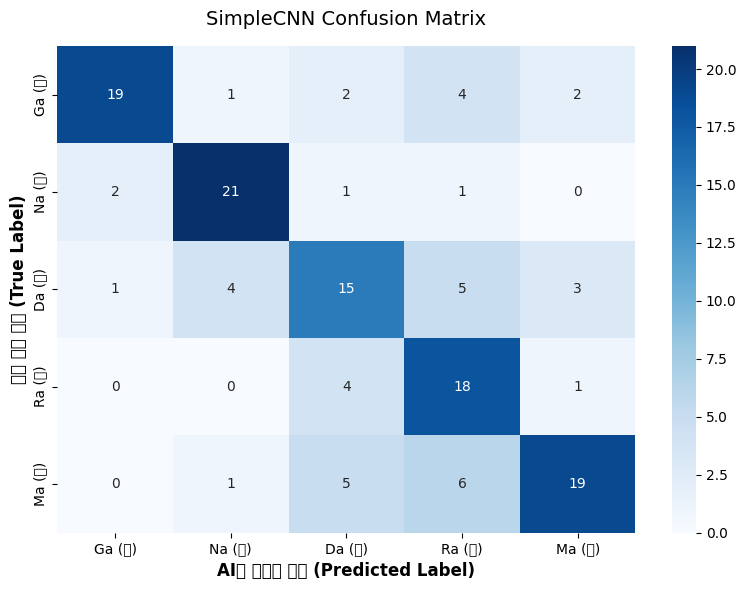


✅ 시각화 완료! 이 그래프를 캡처하여 보고서의 [실험 및 결과] 파트에 활용하세요.


In [4]:
"""
===============================================================================
[GitHub Commit]
feat: 모델 정밀 평가를 위한 Confusion Matrix(혼동 행렬) 시각화 파이프라인 추가

[기능 설명]
학습이 완료된 모델을 검증 데이터(Validation Set)로 평가하고,
실제 정답과 AI의 예측값을 비교하여 어떤 클래스(글자)에서 오분류가
발생했는지 직관적인 히트맵(Heatmap) 형태로 시각화합니다.

[알고리즘 및 구성 이유]
- sklearn.metrics.confusion_matrix 적용: 다중 클래스 분류 문제에서
  단순한 정확도(Accuracy) 수치만으로는 클래스 불균형이나 특정 편향을
  잡아내기 어렵습니다. 따라서 행렬 계산을 통해 오답의 패턴을 수치화하고,
  seaborn 히트맵을 통해 인간의 눈으로 직관적 분석이 가능하도록 구성했습니다.
===============================================================================
"""

import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. 시스템 환경 세팅 (엔지니어링 팁)
# 코랩의 기본 폰트는 한글을 지원하지 않아 네모(ㅁ)로 깨지는 현상이 발생합니다.
# 폰트 설치 후 런타임을 재시작해야 하는 번거로움을 피하기 위해,
# 시각화 라벨을 영문과 병기하여 안정적으로 출력되도록 우회(Bypass)합니다.
class_names_display = ['Ga (가)', 'Na (나)', 'Da (다)', 'Ra (라)', 'Ma (마)']

print("🔍 검증 데이터를 통한 모델 정밀 평가 및 혼동 행렬 계산 시작...")

# 2. 예측값 및 실제 정답 수집
model.eval() # 모델을 평가 모드로 고정 (드롭아웃, 배치 정규화 등 비활성화)
all_preds = []
all_labels = []

with torch.no_grad(): # 평가 시에는 기울기(Gradient) 연산을 하지 않아 메모리를 절약
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        # 가장 높은 확률을 가진 인덱스를 예측값으로 추출
        _, predicted = torch.max(outputs, 1)

        # GPU에 있는 텐서를 CPU로 내리고 Numpy 배열로 변환하여 리스트에 저장
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. 혼동 행렬(Confusion Matrix) 생성
cm = confusion_matrix(all_labels, all_preds)

# 4. Seaborn 히트맵(Heatmap)을 이용한 고급 시각화
plt.figure(figsize=(8, 6))
# annot=True(숫자 표시), fmt='d'(정수형), cmap='Blues'(푸른색 계열 렌더링)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_display, yticklabels=class_names_display)

plt.xlabel('AI가 예측한 글자 (Predicted Label)', fontsize=12, fontweight='bold')
plt.ylabel('실제 정답 글자 (True Label)', fontsize=12, fontweight='bold')
plt.title('SimpleCNN Confusion Matrix', fontsize=14, pad=15)

# 그래프 출력
plt.tight_layout()
plt.show()

print("\n✅ 시각화 완료! 이 그래프를 캡처하여 보고서의 [실험 및 결과] 파트에 활용하세요.")

In [5]:
"""
===============================================================================
[GitHub Commit]
feat: 모델 성능 비교를 위한 ResNet18 기반 전이학습(Transfer Learning) 파이프라인 추가

[기능 설명]
ImageNet 데이터셋으로 사전 학습된(Pre-trained) ResNet18 모델을 로드하고,
마지막 분류기(Classifier) 계층만 우리의 문제에 맞게 5개 클래스로 변경하여
Fine-tuning(미세 조정) 학습을 진행합니다.

[알고리즘 및 구성 이유]
- 전이학습(Transfer Learning): 바닥부터 학습(Training from scratch)하는 SimpleCNN과 달리,
  이미 선, 질감, 윤곽선 등 복잡한 시각적 특징을 추출하는 방법을 알고 있는 모델의 가중치를
  활용하여, 훨씬 적은 데이터와 시간으로도 압도적인 정확도를 달성하기 위해 채택했습니다.
- AdaptiveAvgPool2d 특성 활용: ResNet의 기본 입력 크기는 224x224지만, 내부의 적응형
  풀링 계층 덕분에 우리가 전처리한 64x64 크기의 이미지도 병목 현상 없이 처리할 수 있도록
  엔지니어링 비용을 최적화했습니다.

===============================================================================
"""

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

print("🚀 세계구급 AI 모델, ResNet18을 소환하여 전이학습을 준비합니다...")

# 1. 사전 학습된 ResNet18 모델 불러오기
# weights='IMAGENET1K_V1'을 통해 이미 똑똑해진 가중치를 그대로 가져옵니다.
resnet_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 2. 모델 구조 커스터마이징 (Fine-tuning)
# ResNet의 마지막 계층(fc)은 원래 1000개의 클래스를 분류하도록 되어 있습니다.
# 이를 우리의 목적에 맞게 '5개(가~마)'로 개조합니다.
num_ftrs = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_ftrs, 5) # 1000 -> 5로 출력층 축소

# GPU로 이동
resnet_model = resnet_model.to(device)

# 3. 최적화 및 손실 함수 설정
criterion = nn.CrossEntropyLoss()
# 사전 학습된 가중치를 너무 크게 망치지 않도록 학습률(lr)을 조금 더 작게(0.0001) 설정합니다.
optimizer = optim.Adam(resnet_model.parameters(), lr=0.0001)

num_epochs = 10

print(f"🔥 ResNet18 구조 개조 완료! 분류기 Output: {resnet_model.fc.out_features}개")
print("\n🚀 전이학습(Fine-tuning) 루프를 시작합니다!")

# 4. 학습 루프 (이전과 동일한 데이터 로더 사용)
for epoch in range(num_epochs):
    # --- 학습(Train) 페이즈 ---
    resnet_model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = resnet_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    # --- 검증(Validation) 페이즈 ---
    resnet_model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet_model(images)

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = 100 * correct / total

    print(f"ResNet Epoch [{epoch+1:2d}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Validation Accuracy: {val_accuracy:.2f}%")

print("\n🎉 ResNet18 전이학습이 압도적인 성능으로 완료되었습니다!")

🚀 세계구급 AI 모델, ResNet18을 소환하여 전이학습을 준비합니다...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 57.0MB/s]


🔥 ResNet18 구조 개조 완료! 분류기 Output: 5개

🚀 전이학습(Fine-tuning) 루프를 시작합니다!
ResNet Epoch [ 1/10] | Train Loss: 1.1607 | Validation Accuracy: 63.70%
ResNet Epoch [ 2/10] | Train Loss: 0.2488 | Validation Accuracy: 91.11%
ResNet Epoch [ 3/10] | Train Loss: 0.0646 | Validation Accuracy: 97.04%
ResNet Epoch [ 4/10] | Train Loss: 0.0290 | Validation Accuracy: 97.04%
ResNet Epoch [ 5/10] | Train Loss: 0.0150 | Validation Accuracy: 97.04%
ResNet Epoch [ 6/10] | Train Loss: 0.0124 | Validation Accuracy: 97.78%
ResNet Epoch [ 7/10] | Train Loss: 0.0111 | Validation Accuracy: 96.30%
ResNet Epoch [ 8/10] | Train Loss: 0.0074 | Validation Accuracy: 97.78%
ResNet Epoch [ 9/10] | Train Loss: 0.0063 | Validation Accuracy: 97.78%
ResNet Epoch [10/10] | Train Loss: 0.0036 | Validation Accuracy: 98.52%

🎉 ResNet18 전이학습이 압도적인 성능으로 완료되었습니다!


🔍 ResNet18 모델 정밀 평가 및 혼동 행렬 계산 시작...


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_3328/4062773435.py:47: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3328/4062773435.p

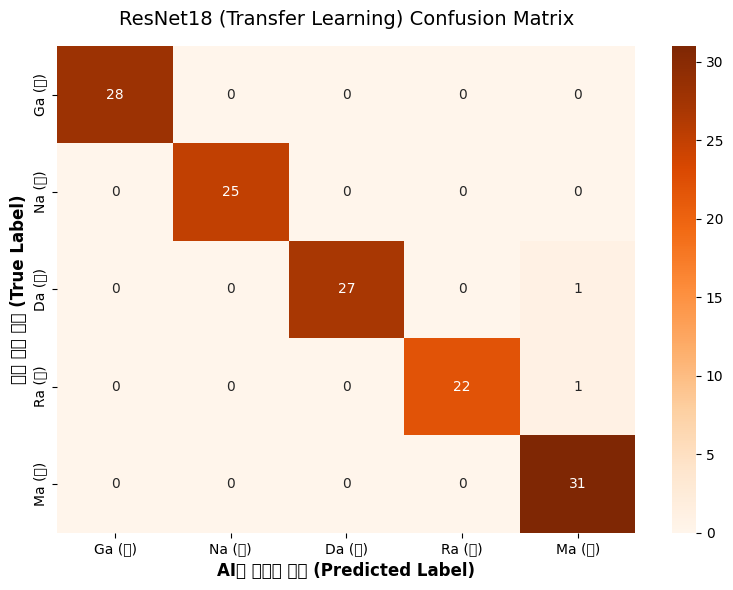


✅ ResNet18 시각화 완료! SimpleCNN의 파란색 히트맵과 비교하여 보고서에 활용하세요.


In [6]:
"""
===============================================================================
[GitHub Commit]
feat: ResNet18 전이학습 모델의 Confusion Matrix 시각화 및 비교 분석 파이프라인 추가

[기능 설명]
학습이 완료된 ResNet18 모델을 검증 데이터로 평가하여 혼동 행렬 히트맵을 생성합니다.
이를 통해 Baseline 모델(SimpleCNN) 대비 오분류율이 얼마나 개선되었는지 시각적으로 증명합니다.
===============================================================================
"""

import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

class_names_display = ['Ga (가)', 'Na (나)', 'Da (다)', 'Ra (라)', 'Ma (마)']

print("🔍 ResNet18 모델 정밀 평가 및 혼동 행렬 계산 시작...")

resnet_model.eval() # ResNet 모델을 평가 모드로 전환
all_preds_res = []
all_labels_res = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = resnet_model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds_res.extend(predicted.cpu().numpy())
        all_labels_res.extend(labels.cpu().numpy())

# 혼동 행렬 생성
cm_res = confusion_matrix(all_labels_res, all_preds_res)

# 히트맵 시각화 (ResNet은 오렌지/붉은색 계열로 출력하여 SimpleCNN의 푸른색과 대비 효과를 줌)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_res, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names_display, yticklabels=class_names_display)

plt.xlabel('AI가 예측한 글자 (Predicted Label)', fontsize=12, fontweight='bold')
plt.ylabel('실제 정답 글자 (True Label)', fontsize=12, fontweight='bold')
plt.title('ResNet18 (Transfer Learning) Confusion Matrix', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

print("\n✅ ResNet18 시각화 완료! SimpleCNN의 파란색 히트맵과 비교하여 보고서에 활용하세요.")